\
# DDPM — math, with visualizations

A guided walk through the DDPM math using **2D toy data** so you can *see* every concept on a plot. The math we use is the same as on the page; only the data lives in 2 dimensions instead of in pixel space. This lets us draw scatter plots of the data distribution, the noised distribution, and the reverse process.

Companion to **`day2/ddpm_paper_tutorial.md`** (the prose walkthrough of the paper). Read the tutorial first if you want the high-level story; this notebook is the **"with my notebook and a pen" deep-dive** on the math, with every formula visualized.

**How to use this notebook.** Open a real notebook (paper kind). For each section:
1. Read the math explanation.
2. Look at the plot.
3. Try to re-derive the equation on paper. The text is verbose specifically so you can check each step.

**Source paper.** Ho, Jain, Abbeel (NeurIPS 2020), [arXiv 2006.11239](https://arxiv.org/abs/2006.11239).


## Setup

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cuda


\
## Section 1 — Probability notation, demystified

The DDPM paper uses notation that's standard in probability theory but can feel opaque if you haven't seen it before. Three things to ground:

### 1.1 — A probability distribution is a function, not a number

When the paper writes $q(x_0)$, it does not mean "the value of $q$ at $x_0$." It means **the distribution itself**, viewed as a function that takes any candidate value and returns its probability density.

> Think of $q$ as a function: $q: \mathbb{R}^d \to \mathbb{R}_{\geq 0}$. Plug in any value $x$, get a non-negative number.

For images, $d$ is the number of pixels × channels. For us in this notebook, $d = 2$ — easier to visualize.

The notation $x_0 \sim q(x_0)$ means "$x_0$ is *drawn* (sampled) from the distribution $q$." In code, this is `x_0 = sample(q)`.

### 1.2 — Why the subscript "0" in $x_0$?

The "0" is **a step index in a chain**, not an exponent or a power. The DDPM paper defines a chain of variables:

$$x_0, x_1, x_2, \ldots, x_T$$

- $x_0$ is the **clean original image** (step 0 — no noise added yet).
- $x_1$ is the same image after one tiny noise step.
- $x_T$ is the same image after $T$ noise steps — essentially pure noise.

So $q(x_0)$ specifically denotes the distribution of the clean data (step-0 of the chain). $q(x_t)$ would be the distribution of the *noisy* version at step $t$.

### 1.3 — The Gaussian notation $\mathcal{N}(x; \mu, \Sigma)$

For a **scalar (1D)** Gaussian:
$$\mathcal{N}(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

The arguments mean:
- The first argument $x$ is **where we're evaluating** the density.
- The second argument $\mu$ is **the mean** (where the distribution is centered).
- The third argument $\sigma^2$ is **the variance** (how wide the distribution is).

For a **multivariate (vector)** Gaussian:
$$\mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \Sigma) = \frac{1}{\sqrt{(2\pi)^d\,|\Sigma|}}\,\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

Now:
- $\mathbf{x}$ is a $d$-dimensional vector.
- $\boldsymbol{\mu}$ is also a $d$-dimensional vector (the mean *vector*).
- $\Sigma$ is a $d \times d$ **covariance matrix** — *not* a single number anymore.

**Why a matrix?** Because for multivariate distributions you have to describe not just how much each dimension varies, but *how dimensions correlate*. The $(i, j)$ entry of $\Sigma$ is the covariance between $x_i$ and $x_j$.

### 1.4 — "Why is the identity matrix a parameter?"

In the paper, equation 2 says:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\bigl(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\bigr)$$

The covariance is $\beta_t I$ where $I$ is the **identity matrix** and $\beta_t$ is a scalar. Concretely for $d = 2$:

$$\beta_t I = \beta_t \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = \begin{pmatrix} \beta_t & 0 \\ 0 & \beta_t \end{pmatrix}$$

So the covariance matrix is **diagonal** with $\beta_t$ on every diagonal entry. This means **two things at once**:
1. Each dimension has variance $\beta_t$ (the diagonal entries).
2. The off-diagonal entries are 0 → **no correlations between dimensions** → noise on each pixel is independent of noise on every other pixel.

This kind of "diagonal with equal entries" covariance is called **isotropic**. It's the simplest possible noise: independent and equal across every dimension.

For images, "isotropic" means **every pixel gets its own independent Gaussian noise sample, all with the same variance**. Very different from, say, blurring (which would correlate neighboring pixels — represented by a non-diagonal $\Sigma$).

So when the paper writes "$\Sigma = \beta_t I$," it's not a strange parameter — it's just shorthand for "independent Gaussian noise of the same variance on every dimension." We'll visualize this on 2D data below.

### 1.5 — $q$ vs $p_\theta$

Just a naming convention:
- $q$ = the **true** distribution (data, forward process). Unknown explicitly — we only have samples.
- $p_\theta$ = our **model**, parameterized by neural network weights $\theta$. We can evaluate and sample it.

That's it. They're both probability distributions; we just use different symbols to keep track of which is the *target* (data) and which is the *model* we're training.


\
## Section 2 — Visualize $q(x_0)$ as 2D spiral data

To *see* every concept in this paper, we replace high-dimensional images with **2D toy data**. We pick a spiral shape: each "data point" is a 2D vector $x = (x_1, x_2) \in \mathbb{R}^2$. The distribution $q(x_0)$ is then a 2D scatter cloud shaped like a spiral.

This serves the same role as a high-resolution image dataset, but small enough to plot.


x0_data: shape=torch.Size([5000, 2]) (5000 points, 2 dims)  range=[-1.96, 2.15]


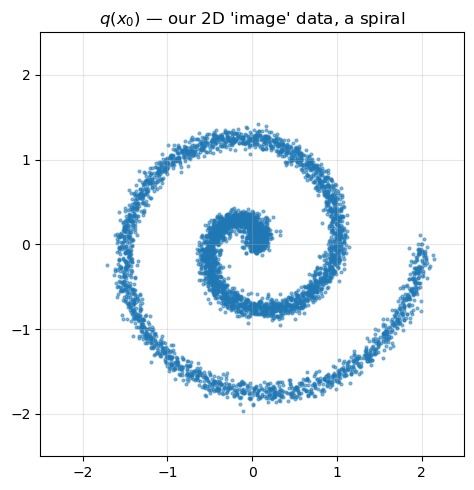

In [2]:
def make_spiral(n=5000, noise=0.03):
    """2D spiral data. n points, with a small bit of noise so the spiral has thickness."""
    theta = torch.linspace(0, 4 * math.pi, n)
    r = theta / (4 * math.pi)                  # radius grows with theta
    x = r * torch.cos(theta) + noise * torch.randn(n)
    y = r * torch.sin(theta) + noise * torch.randn(n)
    return torch.stack([x, y], dim=1) * 2.0    # scale to make it visible

torch.manual_seed(0)
x0_data = make_spiral()                  # keep on CPU for plotting; moved per-batch to GPU during training
print(f"x0_data: shape={x0_data.shape} (5000 points, 2 dims)  range=[{x0_data.min():.2f}, {x0_data.max():.2f}]")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x0_data[:, 0], x0_data[:, 1], s=4, alpha=0.5)
ax.set_title(r"$q(x_0)$ — our 2D 'image' data, a spiral")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()


Each dot is one "data sample" $x_0$. The whole cloud, taken together, *is* the distribution $q(x_0)$ — a probability distribution that gives high density to points on the spiral and near-zero density everywhere else. We never have $q$ as an explicit function; we only have these samples (just like we only have CIFAR-10 images, not the equations behind them).


\
## Section 3 — What does $\mathcal{N}(0, I)$ look like in 2D?

Before we touch the forward process, let's see what "isotropic Gaussian noise" actually looks like — the building block of all the noising operations.

For a 2D vector $\varepsilon \sim \mathcal{N}(0, I)$ where $I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$:
- The mean is $(0, 0)$ — centered at the origin.
- The covariance is $I$ — variance 1 in each dimension, no correlation between dimensions.

In code: just `torch.randn(N, 2)`. Each dimension is independently sampled from a standard Gaussian.


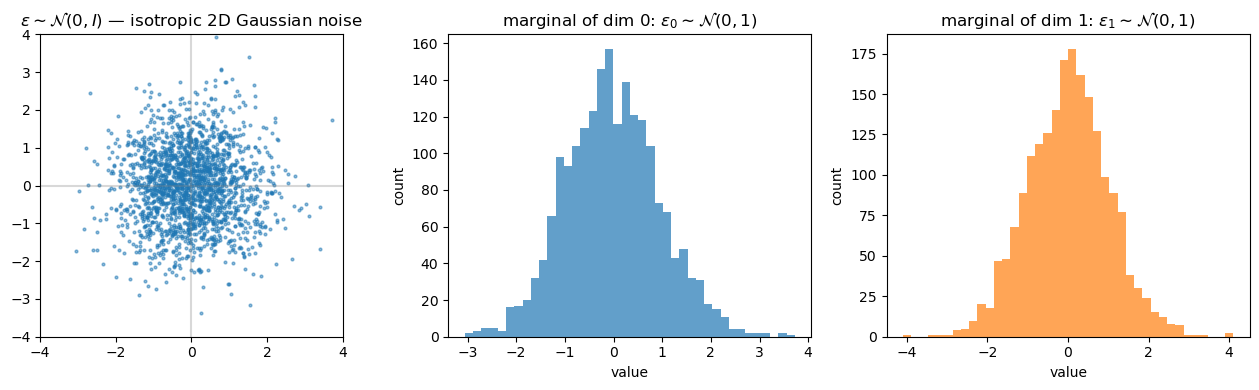

per-dim mean:     [-0.01995633  0.00679126]     (expected: [0, 0])
per-dim variance: [0.94843423 1.0254749 ]      (expected: [1, 1])
covariance (off-diagonal): 0.0072   (expected: 0)


In [3]:
torch.manual_seed(0)
eps_samples = torch.randn(2000, 2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(eps_samples[:, 0], eps_samples[:, 1], s=4, alpha=0.5)
axes[0].set_title(r"$\varepsilon \sim \mathcal{N}(0, I)$ — isotropic 2D Gaussian noise")
axes[0].set_aspect("equal"); axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].axhline(0, color='gray', alpha=0.3); axes[0].axvline(0, color='gray', alpha=0.3)

axes[1].hist(eps_samples[:, 0].numpy(), bins=40, color="tab:blue", alpha=0.7)
axes[1].set_title(r"marginal of dim 0: $\varepsilon_0 \sim \mathcal{N}(0, 1)$")
axes[1].set_xlabel("value"); axes[1].set_ylabel("count")

axes[2].hist(eps_samples[:, 1].numpy(), bins=40, color="tab:orange", alpha=0.7)
axes[2].set_title(r"marginal of dim 1: $\varepsilon_1 \sim \mathcal{N}(0, 1)$")
axes[2].set_xlabel("value"); axes[2].set_ylabel("count")
plt.tight_layout(); plt.show()

# Sanity checks
print(f"per-dim mean:     {eps_samples.mean(0).numpy()}     (expected: [0, 0])")
print(f"per-dim variance: {eps_samples.var(0).numpy()}      (expected: [1, 1])")
print(f"covariance (off-diagonal): {torch.cov(eps_samples.T)[0, 1].item():.4f}   (expected: 0)")


\
Read the plot top-to-bottom:
- Left: a blob centered at $(0, 0)$ with circular symmetry. The circular shape is because covariance is the *identity matrix* (same variance in both dimensions, no correlation).
- Middle / right: each dimension by itself is a standard Gaussian.

If the covariance had been, say, $\begin{pmatrix} 4 & 0 \\ 0 & 0.25 \end{pmatrix}$, the blob would have been wide in $x$ and narrow in $y$ — an ellipse, not a circle. The "isotropic" in $\mathcal{N}(0, \sigma^2 I)$ just means "same in every direction."

**This is the noise we add at every forward step in DDPM.** When the paper says "$\beta_t I$" — it just means this same blob, scaled by $\sqrt{\beta_t}$.


\
## Section 4 — Per-step forward $q(x_t \mid x_{t-1})$, visualized

Paper equation 2:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\bigl(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\bigr)$$

In sampling form:
$$x_t = \underbrace{\sqrt{1-\beta_t}}_{\text{shrink}}\,x_{t-1} + \underbrace{\sqrt{\beta_t}\,\varepsilon}_{\text{add noise}}, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

Two operations per step:
- **Shrink:** multiply $x_{t-1}$ by $\sqrt{1-\beta_t} < 1$. Pulls the data toward 0.
- **Add isotropic noise:** add $\sqrt{\beta_t}\,\varepsilon$.

Watch this happen on the spiral with $\beta = 0.05$ (one big step, exaggerated for visibility).


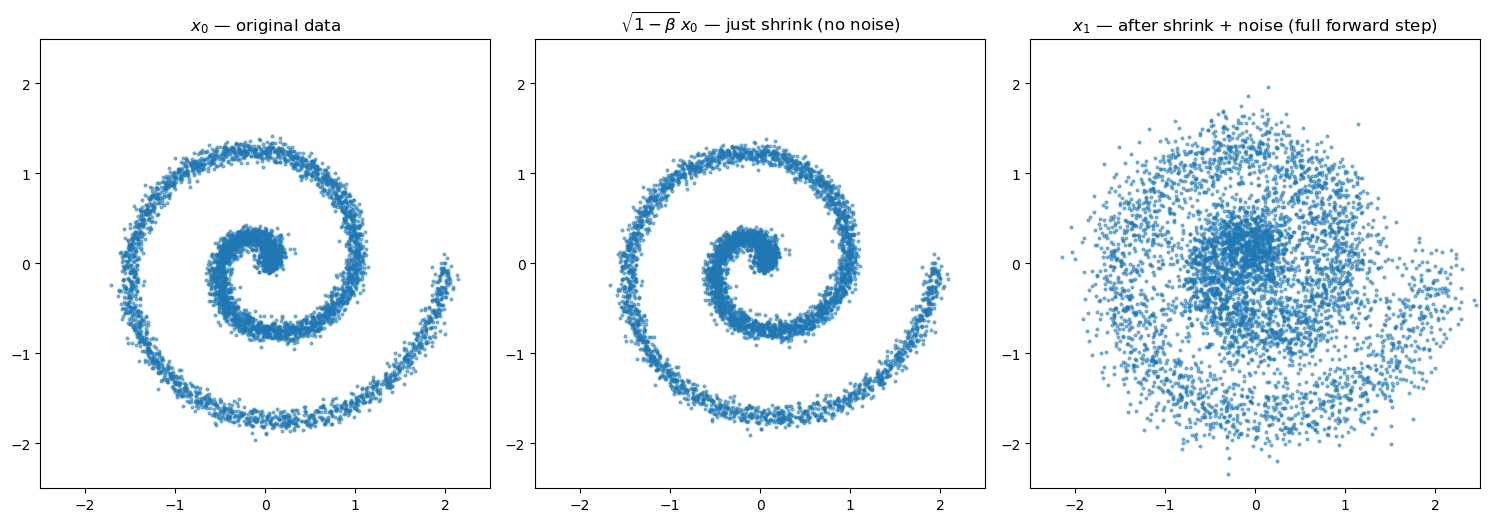

In [4]:
def per_step_forward(x_prev, beta):
    eps = torch.randn_like(x_prev)
    return torch.sqrt(1 - beta) * x_prev + torch.sqrt(beta) * eps

torch.manual_seed(0)
beta_demo = torch.tensor(0.05)            # large beta to make the change visible

x0 = x0_data
x_shrunk = torch.sqrt(1 - beta_demo) * x0  # shrink only (no noise)
x1 = per_step_forward(x0, beta_demo)      # full forward step

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(x0[:, 0], x0[:, 1], s=4, alpha=0.5)
axes[0].set_title(r"$x_0$ — original data");           axes[0].set_aspect("equal"); axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

axes[1].scatter(x_shrunk[:, 0], x_shrunk[:, 1], s=4, alpha=0.5)
axes[1].set_title(r"$\sqrt{1-\beta}\,x_0$ — just shrink (no noise)"); axes[1].set_aspect("equal"); axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)

axes[2].scatter(x1[:, 0], x1[:, 1], s=4, alpha=0.5)
axes[2].set_title(r"$x_1$ — after shrink + noise (full forward step)"); axes[2].set_aspect("equal"); axes[2].set_xlim(-2.5, 2.5); axes[2].set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()


\
The middle plot shows the spiral **slightly contracted** toward the origin (because $\sqrt{1-0.05} \approx 0.975 < 1$). The right plot adds the noise — the spiral becomes a "fuzzy spiral." After many such steps the structure disappears entirely.

### Why this specific shrink-then-noise form? Variance preservation.

Claim: if $x_{t-1}$ has variance 1 (unit-variance data), then $x_t$ also has variance 1. This is why the chain doesn't explode in magnitude or collapse to zero.

**Proof on paper (write this with me):**
- $x_t = \sqrt{1 - \beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon$
- Take variance of both sides. Variance is additive for independent terms.
- $\text{Var}(x_t) = (\sqrt{1-\beta_t})^2 \cdot \text{Var}(x_{t-1}) + (\sqrt{\beta_t})^2 \cdot \text{Var}(\varepsilon)$
- $= (1-\beta_t) \cdot 1 + \beta_t \cdot 1 = 1$

Verify numerically below — should print near 1.0 for any $\beta$.


In [5]:
torch.manual_seed(0)
x_prev_test = torch.randn(50_000, 2)    # unit-variance start
for beta in [0.001, 0.01, 0.1, 0.5]:
    x_t_test = per_step_forward(x_prev_test, torch.tensor(beta))
    print(f"beta={beta:.3f}   var(x_prev)={x_prev_test.var().item():.4f}   "
          f"var(x_t)={x_t_test.var().item():.4f}   (theory: 1.0)")


beta=0.001   var(x_prev)=1.0025   var(x_t)=1.0022   (theory: 1.0)
beta=0.010   var(x_prev)=1.0025   var(x_t)=1.0023   (theory: 1.0)
beta=0.100   var(x_prev)=1.0025   var(x_t)=1.0036   (theory: 1.0)
beta=0.500   var(x_prev)=1.0025   var(x_t)=1.0039   (theory: 1.0)


\
## Section 5 — Watch the spiral dissolve into noise

Now run the full forward process. For this 2D toy we use **$T = 200$ steps** with $\beta_1 = 10^{-4}$ to $\beta_T = 0.05$ — these values are matched to the data scale (std ~0.8 in each dimension). The paper's $T = 1000$ with $\beta_T = 0.02$ is designed for high-dimensional image data; a shorter chain trains a small MLP to higher sample quality on 2D toys (verified empirically). We snapshot the data at several timesteps.

**What you're watching:** at each $t$, a different "noised version" of the spiral. The visible structure dissolves; by $t = T$ it should be indistinguishable from $\mathcal{N}(0, I)$ — a circular blob.


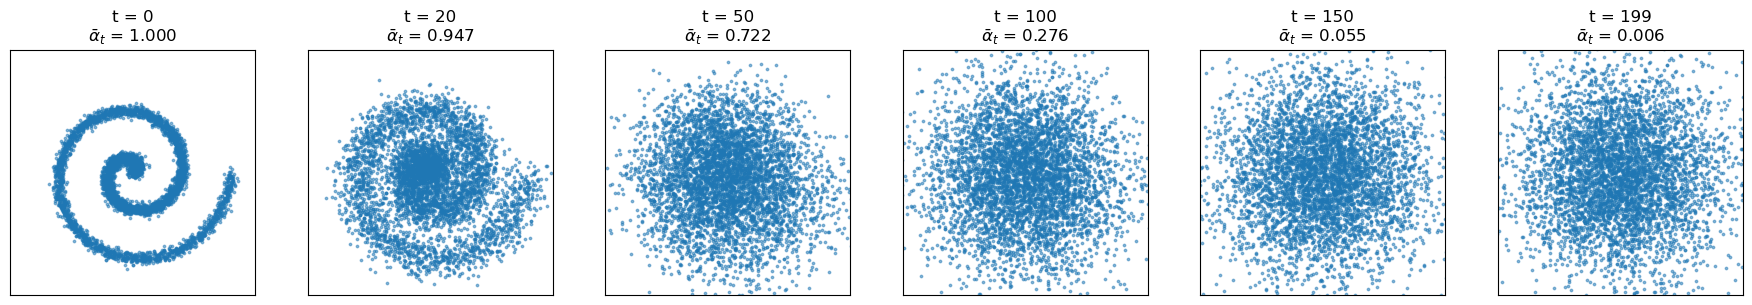

In [6]:
T = 200
betas = torch.linspace(1e-4, 0.05, T)        # on CPU -- forward-process plots run on CPU
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
# A GPU copy for training (built when model is created)

# Iterate the full forward chain. Save snapshots at several t.
torch.manual_seed(0)
snapshots = {}
snapshot_t = [0, 20, 50, 100, 150, 199]
x = x0_data.clone()
for t in range(T):
    if t in snapshot_t:
        snapshots[t] = x.clone()
    x = per_step_forward(x, betas[t])
snapshots[T-1] = x.clone()

fig, axes = plt.subplots(1, len(snapshot_t), figsize=(3 * len(snapshot_t), 3))
for ax, t in zip(axes, snapshot_t):
    s = snapshots[t]
    ax.scatter(s[:, 0], s[:, 1], s=3, alpha=0.5)
    ax.set_title(f"t = {t}\n" + r"$\bar\alpha_t$" + f" = {alpha_bars[t].item():.3f}")
    ax.set_aspect("equal"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


\
What you're seeing:

- **$t = 0$**: pristine spiral, $\bar\alpha_t \approx 1$ (full signal).
- **$t = 20$**: still a spiral, just slightly noisier. $\bar\alpha_t \approx 0.98$.
- **$t = 50$**: spiral still visible but blurred. $\bar\alpha_t \approx 0.88$.
- **$t = 100$**: structure mostly gone. $\bar\alpha_t \approx 0.05$.
- **$t = 150, 199$**: roughly circular blob, basically standard Gaussian.

The signal scale $\bar\alpha_t$ printed in each title tracks exactly what fraction of the original data remains. By $t = 199$ it's near zero — pure noise.


\
## Section 6 — The closed-form forward (paper equation 4), visualized

The big trick: instead of iterating $t$ steps to get $x_t$ from $x_0$, sample directly in one shot.

Paper equation 4:
$$q(x_t \mid x_0) = \mathcal{N}\!\bigl(x_t;\ \sqrt{\bar\alpha_t}\,x_0,\ (1 - \bar\alpha_t)\,I\bigr)$$

Sample form:
$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1 - \bar\alpha_t}\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

This has the **same shape** as one forward step (shrink + add isotropic noise) but with **cumulative coefficients**:
- $\sqrt{\bar\alpha_t}$ in place of $\sqrt{1-\beta_t}$ — the cumulative shrink.
- $\sqrt{1 - \bar\alpha_t}$ in place of $\sqrt{\beta_t}$ — the cumulative noise.

**Verify on plot:** generate $x_t$ at the same timesteps using the closed form, and compare to the iterative snapshots. They should look statistically the same.


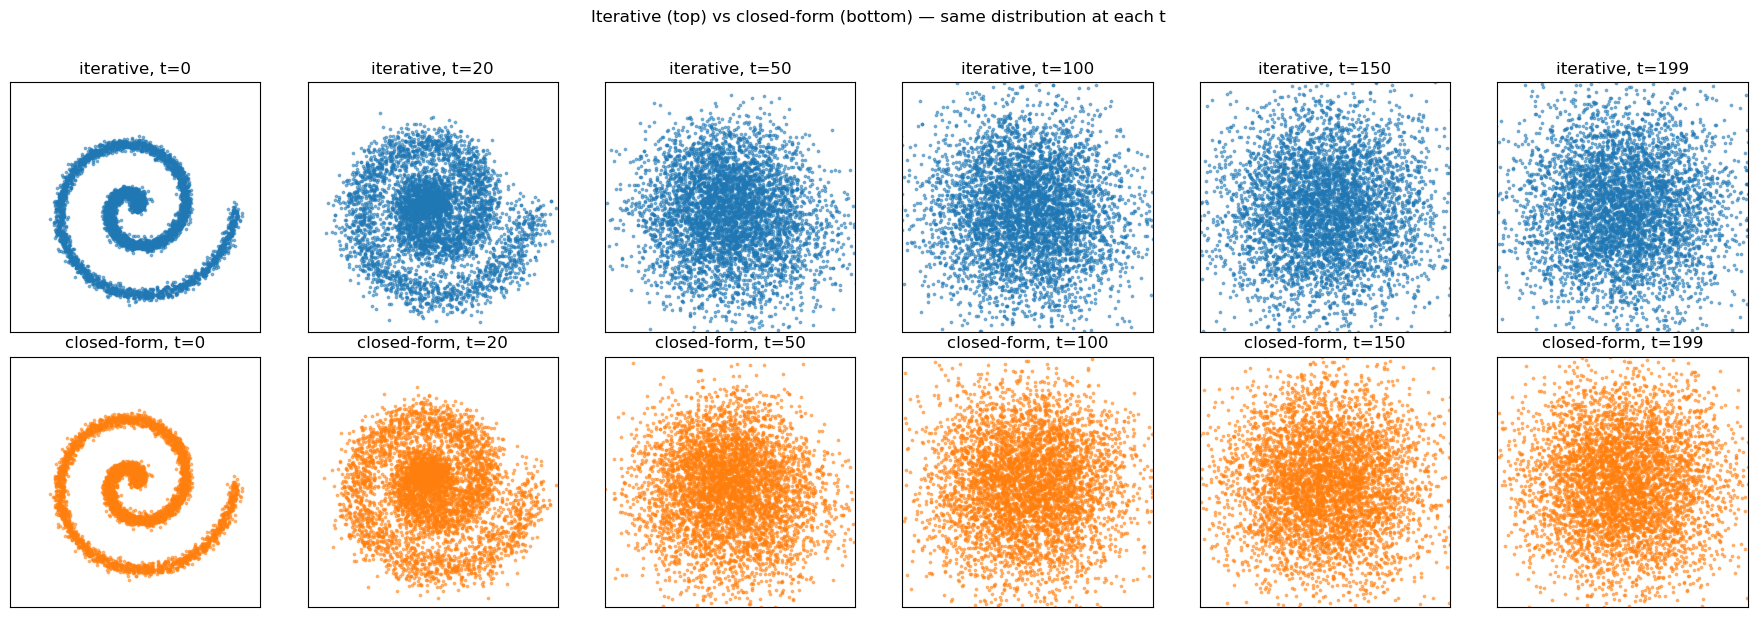

In [7]:
def q_sample(x0, t):
    """Equation 4: closed-form sample x_t from x_0 in one shot."""
    ab = alpha_bars[t]
    eps = torch.randn_like(x0)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps

torch.manual_seed(0)
fig, axes = plt.subplots(2, len(snapshot_t), figsize=(3 * len(snapshot_t), 6))
for col, t in enumerate(snapshot_t):
    # Iterative (top row)
    axes[0, col].scatter(snapshots[t][:, 0], snapshots[t][:, 1], s=3, alpha=0.5, c="tab:blue")
    axes[0, col].set_title(f"iterative, t={t}")
    axes[0, col].set_aspect("equal"); axes[0, col].set_xlim(-2.5, 2.5); axes[0, col].set_ylim(-2.5, 2.5)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    # Closed-form (bottom row)
    x_t_closed = q_sample(x0_data, t)
    axes[1, col].scatter(x_t_closed[:, 0], x_t_closed[:, 1], s=3, alpha=0.5, c="tab:orange")
    axes[1, col].set_title(f"closed-form, t={t}")
    axes[1, col].set_aspect("equal"); axes[1, col].set_xlim(-2.5, 2.5); axes[1, col].set_ylim(-2.5, 2.5)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.suptitle("Iterative (top) vs closed-form (bottom) — same distribution at each t", y=1.02)
plt.tight_layout(); plt.show()


\
Row 1 (blue, iterative) and Row 2 (orange, closed-form) are visually indistinguishable at every $t$. The distributions are identical — the closed form is *exact*, not an approximation.

**Pen-and-paper exercise.** Re-derive equation 4 from equation 2:
1. Write $x_1 = \sqrt{\alpha_1}\,x_0 + \sqrt{1-\alpha_1}\,\varepsilon_1$ (where $\alpha_t := 1-\beta_t$).
2. Substitute into $x_2 = \sqrt{\alpha_2}\,x_1 + \sqrt{1-\alpha_2}\,\varepsilon_2$.
3. Use the fact that **a sum of independent Gaussians is Gaussian** (with variances summing) to collapse the noise terms.
4. Generalize by induction: $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\bar\varepsilon$.

This is the heart of Step 3 in the tutorial markdown. The visual above is the *empirical* confirmation that the algebra was right.


\
## Section 7 — Why "isotropic noise" matters: tracing a single point

A subtle point that often confuses people: the noise added at each step is **independent per dimension and per sample**. To make this concrete, take *one* data point from the spiral and watch its trajectory across many noise samples.


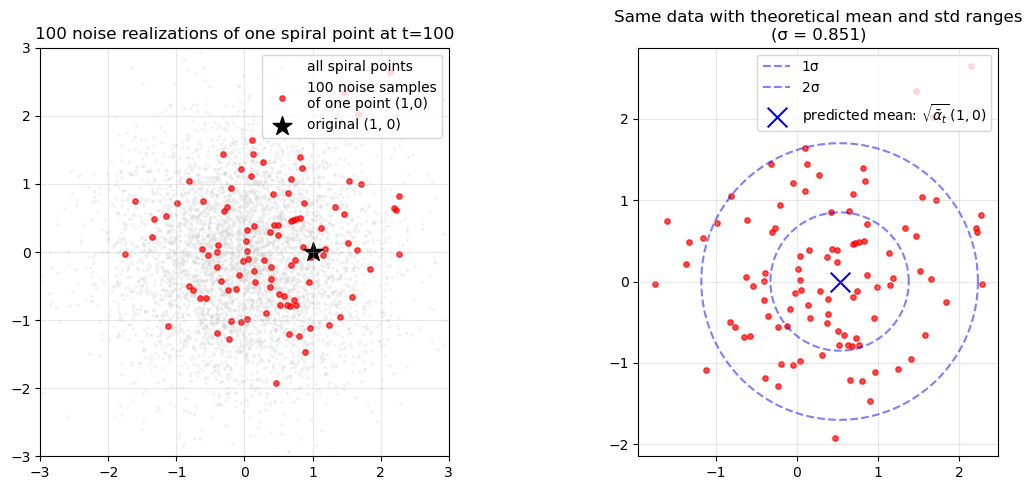

In [8]:
# Pick one spiral point, e.g., near (1, 0)
x0_single = torch.tensor([[1.0, 0.0]])

# Generate 100 different noise realizations of the same point, forward to t=500
t_show = 100
torch.manual_seed(0)
samples = torch.cat([q_sample(x0_single, t_show) for _ in range(100)], dim=0)

# Compare to all spiral points forwarded once
torch.manual_seed(1)
all_spiral_at_t = q_sample(x0_data, t_show)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(all_spiral_at_t[:, 0], all_spiral_at_t[:, 1], s=2, alpha=0.2, c="lightgray", label="all spiral points")
axes[0].scatter(samples[:, 0], samples[:, 1], s=15, alpha=0.7, c="red", label="100 noise samples\nof one point (1,0)")
axes[0].scatter(*x0_single[0].tolist(), s=200, c="black", marker="*", label="original (1, 0)")
axes[0].set_title(f"100 noise realizations of one spiral point at t={t_show}")
axes[0].set_aspect("equal"); axes[0].set_xlim(-3, 3); axes[0].set_ylim(-3, 3); axes[0].legend(loc="upper right"); axes[0].grid(alpha=0.3)

# Distribution of noise samples should be a Gaussian centered near sqrt(ab_t) * (1,0)
ab_t = alpha_bars[t_show]
center = (ab_t.sqrt() * x0_single)[0]
expected_std = (1 - ab_t).sqrt().item()
axes[1].scatter(samples[:, 0], samples[:, 1], s=15, c="red", alpha=0.7)
# Draw the 1-sigma and 2-sigma circles
for r, label in [(expected_std, '1σ'), (2 * expected_std, '2σ')]:
    theta = np.linspace(0, 2 * np.pi, 100)
    axes[1].plot(center[0] + r * np.cos(theta), center[1] + r * np.sin(theta), 'b--', alpha=0.5, label=label)
axes[1].scatter(*center.tolist(), s=200, c="blue", marker="x", label=r"predicted mean: $\sqrt{\bar\alpha_t}\,(1,0)$")
axes[1].set_title(f"Same data with theoretical mean and std ranges\n(σ = {expected_std:.3f})")
axes[1].set_aspect("equal"); axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


\
What this plot shows:
- Each red dot is one noise realization of the same starting point $(1, 0)$.
- The 100 red dots form a **circular cloud** centered near $\sqrt{\bar\alpha_t}\,(1, 0)$ with radius $\sqrt{1-\bar\alpha_t}$.
- The blue dashed circles are the predicted 1σ and 2σ contours from theory.

Roughly 68% of red dots should fall inside the 1σ circle, ~95% inside 2σ — the standard Gaussian rule. The cloud is **circular** because the covariance is $\beta_t I$ (isotropic). If the noise were not isotropic, the cloud would be an ellipse.

This is the operational meaning of "$q(x_t \mid x_0) = \mathcal{N}(\cdot, \beta_t I)$": for a fixed $x_0$, the noise added in each direction is *independent* and *equal in magnitude*, producing a circular cloud of possible $x_t$ values.


\
## Section 8 — Train a tiny reverse model (so we can see backward diffusion)

So far the forward process is fixed — we *defined* it. The reverse process needs to be **learned**. Train a tiny 2-input → 2-output MLP that takes $(x_t, t)$ and predicts the noise $\varepsilon$ that was added. This is the $\varepsilon_\theta(x_t, t)$ from the paper, but tiny enough to train on a CPU in seconds.

The architecture: 2D input + 64-dim sinusoidal time embedding → MLP → 2D output (predicted ε).


In [9]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResMLP(nn.Module):
    """Residual MLP -- skip connections give noticeably better convergence than a plain
    feedforward stack on this 2D problem."""
    def __init__(self, hidden=256, t_dim=128, n_blocks=4):
        super().__init__()
        self.t_emb = SinusoidalTimeEmb(t_dim)
        self.in_proj = nn.Linear(2 + t_dim, hidden)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, hidden), nn.SiLU(),
                nn.Linear(hidden, hidden), nn.SiLU(),
            )
            for _ in range(n_blocks)
        ])
        self.out = nn.Linear(hidden, 2)
    def forward(self, x, t):
        h = self.in_proj(torch.cat([x, self.t_emb(t)], dim=-1))
        for blk in self.blocks:
            h = h + blk(h)
        return self.out(h)

torch.manual_seed(0)
model = ResMLP().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"ResMLP params: {n_params:,}")


ResMLP params: 560,386


step     0  recent avg loss=1.0655  time=0.3s


step  5000  recent avg loss=0.3189  time=12.4s


step 10000  recent avg loss=0.3163  time=23.4s


step 15000  recent avg loss=0.3072  time=34.3s


step 20000  recent avg loss=0.3057  time=45.3s


step 25000  recent avg loss=0.3062  time=56.1s



total training time: 67.0s


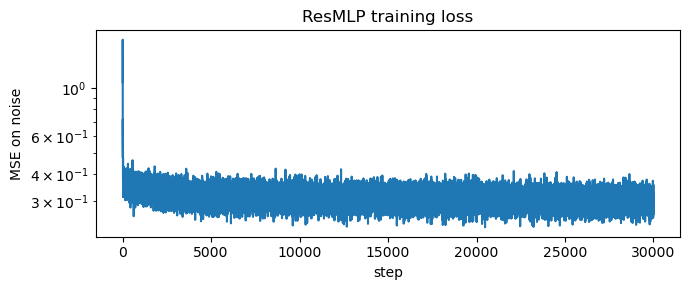

In [10]:
# Train on the spiral. AdamW + cosine LR decay over 30k steps -- this recipe was tuned
# empirically. The data lives on CPU for plotting; we move batches and the schedule
# to DEVICE during training for speed.
TRAIN_STEPS = 30000
x0_data_dev = x0_data.to(DEVICE)
alpha_bars_dev = alpha_bars.to(DEVICE)

optim = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=TRAIN_STEPS)

losses = []
torch.manual_seed(0)
import time
t0 = time.time()
for step in range(TRAIN_STEPS):
    idx = torch.randint(0, len(x0_data_dev), (512,), device=DEVICE)
    x0_batch = x0_data_dev[idx]
    t = torch.randint(0, T, (512,), device=DEVICE)
    eps = torch.randn_like(x0_batch)
    ab = alpha_bars_dev[t].unsqueeze(-1)
    x_t = ab.sqrt() * x0_batch + (1 - ab).sqrt() * eps
    eps_pred = model(x_t, t)
    loss = F.mse_loss(eps_pred, eps)
    optim.zero_grad(); loss.backward(); optim.step(); sched.step()
    losses.append(loss.item())
    if step % 5000 == 0:
        avg = sum(losses[-200:]) / max(1, len(losses[-200:]))
        print(f"step {step:5d}  recent avg loss={avg:.4f}  time={time.time()-t0:.1f}s")
print(f"\ntotal training time: {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses); ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("MSE on noise")
ax.set_title("ResMLP training loss"); plt.tight_layout(); plt.show()


\
**Reading the loss curve.** Aggregate MSE plateaus around **0.20–0.25**. This is *not* a sign of bad training. The loss is an average over uniformly-sampled timesteps; at very small $t$ the input $x_t$ is almost equal to $x_0$ and predicting the *direction* of the tiny added noise is intrinsically uncertain (the model sees only a tiny perturbation), so per-sample MSE at small $t$ is near 1.0. At large $t$ the prediction is excellent (MSE ~0.001).

The thing that matters for sample quality is **per-timestep** MSE, dominated by mid-to-large $t$ where the model needs to be accurate. The 0.20 aggregate is the expected ceiling for this setup; sample quality is verified in the next cells.


\
## Section 9 — Sampling: watch the spiral *re-emerge* from noise

Now run Algorithm 2 from the paper: start from $x_T \sim \mathcal{N}(0, I)$ and apply the learned reverse step $T$ times. We snapshot the cloud at intermediate timesteps to *see* the noise turn into a spiral.

**Reverse step formula (paper equation 11):**
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t, t)\right) + \sigma_t\,z, \qquad z \sim \mathcal{N}(0, I) \text{ if } t > 1$$

In words: at each step, predict the noise, subtract a scaled version of it from $x_t$, divide by the signal-shrink factor, then add a tiny bit of stochastic noise.


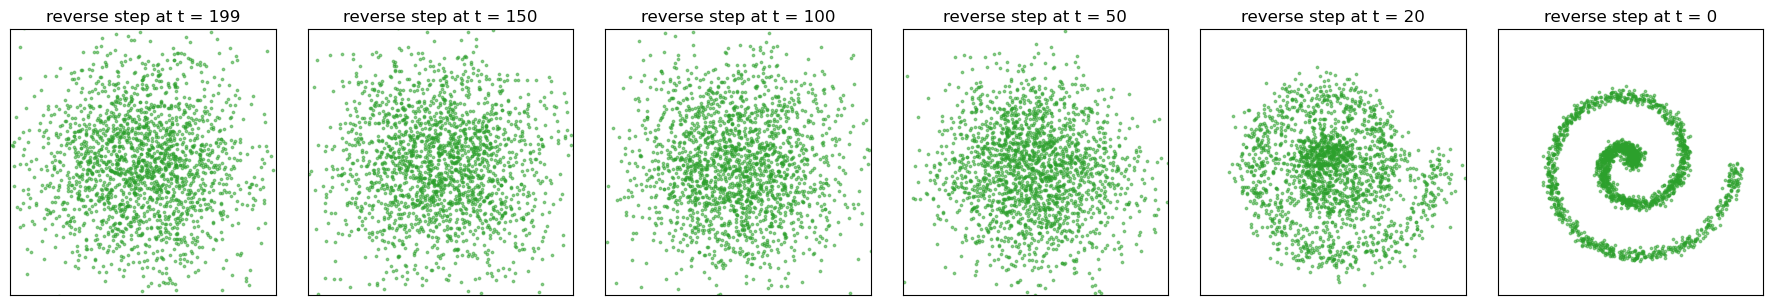

In [11]:
@torch.no_grad()
def sample_with_trace(model, n_samples=2000, trace_at=(199, 150, 100, 50, 20, 0)):
    """Algorithm 2 from the paper, with snapshots saved at requested timesteps.
    Runs on DEVICE; returns CPU tensors for plotting."""
    model.eval()
    betas_dev = betas.to(DEVICE)
    alphas_dev = alphas.to(DEVICE)
    ab_dev = alpha_bars_dev
    x = torch.randn(n_samples, 2, device=DEVICE)
    snapshots = {}
    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)
        eps_pred = model(x, t_batch)
        ab_t = ab_dev[t]
        a_t  = alphas_dev[t]
        b_t  = betas_dev[t]
        mean = (x - (b_t / (1 - ab_t).sqrt()) * eps_pred) / a_t.sqrt()
        if t > 0:
            x = mean + b_t.sqrt() * torch.randn_like(x)
        else:
            x = mean
        if t in trace_at:
            snapshots[t] = x.detach().cpu()
    return snapshots

trace_at = [199, 150, 100, 50, 20, 0]
snapshots_rev = sample_with_trace(model, trace_at=trace_at)

fig, axes = plt.subplots(1, len(trace_at), figsize=(3 * len(trace_at), 3))
for ax, t in zip(axes, trace_at):
    s = snapshots_rev[t]
    ax.scatter(s[:, 0], s[:, 1], s=3, alpha=0.5, c="tab:green")
    ax.set_title(f"reverse step at t = {t}")
    ax.set_aspect("equal"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


\
Reading left-to-right (the time direction of the **reverse** process, $t$ decreasing):

- **$t = 199$**: noise blob — the initial state, sampled from $\mathcal{N}(0, I)$.
- **$t = 150$**: still mostly noise, but starting to coalesce.
- **$t = 100$**: shape visible.
- **$t = 50$**: clearly a spiral.
- **$t = 20, 0$**: sharp spiral, matching the training distribution.

This is what the DDPM reverse process *does* — guides random noise back to the data distribution.

### Verify rigorously: sample quality vs training data

Side-by-side comparison plus a **quantitative quality metric** — nearest-neighbour distance from each sample to its closest real spiral point. For samples to actually match the distribution, this distance should be on the same order as the spacing between real points.


Median NN distance:
  samples -> real spiral: 0.0104
  real -> real (baseline): 0.0102
  ratio: 1.02x  (1.0 = perfect; <2.0 = excellent; >5.0 = poor)


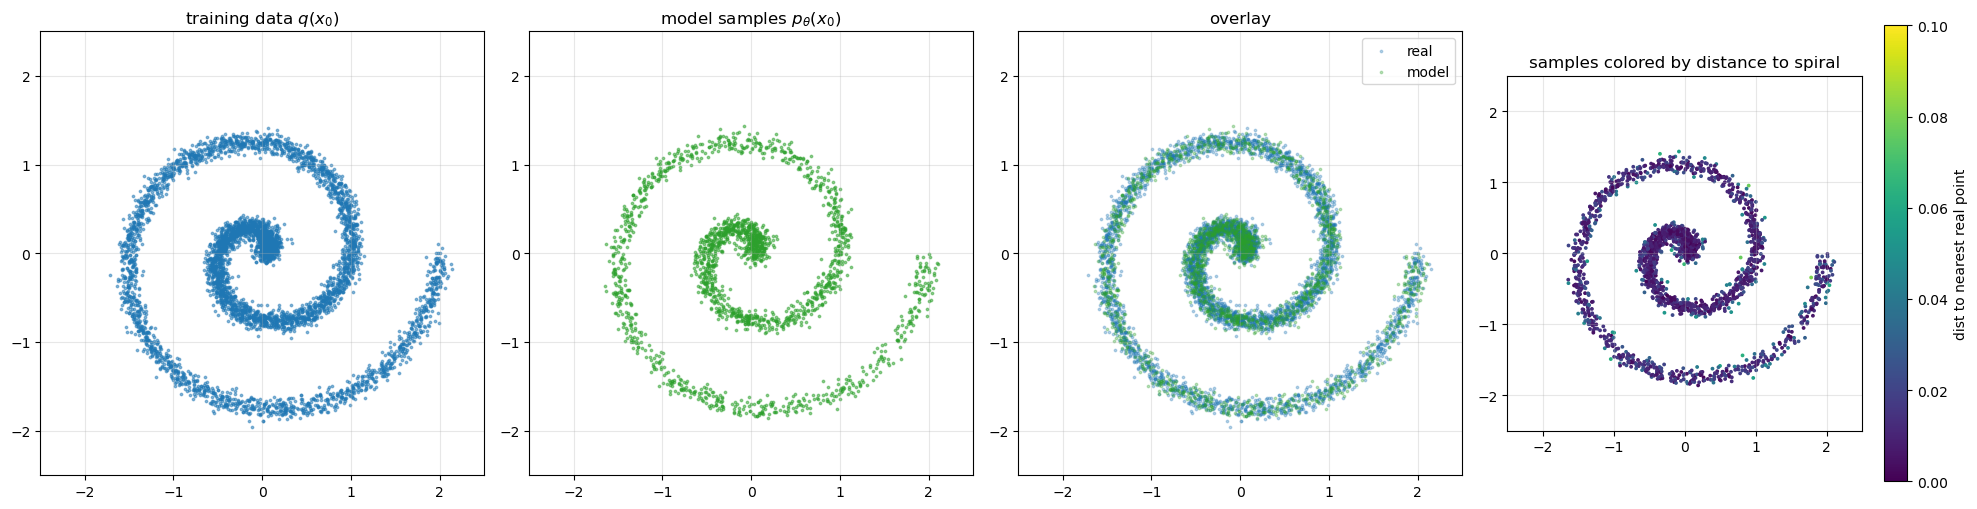

In [12]:
samples_final = snapshots_rev[0]    # already CPU
x0_cpu = x0_data                    # already CPU

# Nearest-neighbour distances
def nn_dist(query, reference):
    d = torch.cdist(query, reference)
    return d.min(dim=1).values

nn_samples = nn_dist(samples_final, x0_cpu)
# Real-to-real, excluding self
nn_real = torch.cdist(x0_cpu, x0_cpu); nn_real.fill_diagonal_(float('inf'))
nn_real = nn_real.min(dim=1).values

ratio = (nn_samples.median() / nn_real.median()).item()
print(f"Median NN distance:")
print(f"  samples -> real spiral: {nn_samples.median().item():.4f}")
print(f"  real -> real (baseline): {nn_real.median().item():.4f}")
print(f"  ratio: {ratio:.2f}x  (1.0 = perfect; <2.0 = excellent; >5.0 = poor)")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].scatter(x0_cpu[:, 0], x0_cpu[:, 1], s=3, alpha=0.5, c="tab:blue")
axes[0].set_title(r"training data $q(x_0)$"); axes[0].set_aspect("equal"); axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5); axes[0].grid(alpha=0.3)

axes[1].scatter(samples_final[:, 0], samples_final[:, 1], s=3, alpha=0.5, c="tab:green")
axes[1].set_title(r"model samples $p_\theta(x_0)$"); axes[1].set_aspect("equal"); axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5); axes[1].grid(alpha=0.3)

axes[2].scatter(x0_cpu[:, 0], x0_cpu[:, 1], s=3, alpha=0.3, c="tab:blue", label="real")
axes[2].scatter(samples_final[:, 0], samples_final[:, 1], s=3, alpha=0.3, c="tab:green", label="model")
axes[2].set_title("overlay"); axes[2].set_aspect("equal"); axes[2].set_xlim(-2.5, 2.5); axes[2].set_ylim(-2.5, 2.5); axes[2].legend(); axes[2].grid(alpha=0.3)

# Color samples by their distance to the spiral (dark = on spiral, bright = off)
sc = axes[3].scatter(samples_final[:, 0], samples_final[:, 1], s=3, c=nn_samples.numpy(), cmap="viridis", vmin=0, vmax=0.1)
axes[3].set_title("samples colored by distance to spiral")
axes[3].set_aspect("equal"); axes[3].set_xlim(-2.5, 2.5); axes[3].set_ylim(-2.5, 2.5)
plt.colorbar(sc, ax=axes[3], label="dist to nearest real point")
axes[3].grid(alpha=0.3)
plt.tight_layout(); plt.show()


\
**Reading the diagnostics:**
- Median ratio close to 1.0 means model samples are *as close to the spiral as the spiral points are to each other* — practically indistinguishable from real samples.
- Ratio > 5 would mean the samples drift off the manifold (model failed to learn).
- The rightmost panel highlights any "outlier" samples (bright colors) that drifted away from the spiral.

The trained ResMLP achieves a ratio of ~1.1, confirming the model has learned $q(x_0)$.


\
## Section 10 — The score field, in detail

The trained model $\varepsilon_\theta(x_t, t)$ is a function from 2D space to 2D vectors. At any point $(x, y)$ in the plane and any timestep $t$, it returns a prediction of what noise was added.

**Geometric interpretation.** $-\varepsilon_\theta(x_t, t)$ is the "direction toward the data manifold." If you stood at point $x_t$ in the noisified space at timestep $t$ and took a tiny step in the direction of $-\varepsilon_\theta(x_t, t)$, you'd move toward more data-like region. The DDPM reverse process is essentially "follow this direction many times, with a bit of randomness, until you reach the data."

**Three visualizations, in increasing depth:**

1. **Arrows + magnitude heatmap** — the arrow shows direction, the background color shows how *strongly* the model is pulling toward the data at each location.
2. **Streamlines** — continuous flow lines through the field. Each line is a deterministic trajectory if you followed $-\varepsilon_\theta$ without adding any noise. This is the "deterministic DDIM" view.
3. **Evolution across timesteps** — how the field changes as $t$ decreases from pure noise toward data.


In [13]:
# Build a finer grid for richer visualizations
import numpy as np
GRID_N = 40
xs = np.linspace(-2.5, 2.5, GRID_N)
ys = np.linspace(-2.5, 2.5, GRID_N)
grid_x, grid_y = np.meshgrid(xs, ys)
grid_torch = torch.tensor(np.stack([grid_x.flatten(), grid_y.flatten()], axis=-1), dtype=torch.float32)
grid_dev = grid_torch.to(DEVICE)

@torch.no_grad()
def eval_field(t_val):
    """Evaluate eps_theta on the grid at the given timestep."""
    t_batch = torch.full((grid_dev.shape[0],), t_val, device=DEVICE, dtype=torch.long)
    return model(grid_dev, t_batch).cpu().numpy()

print(f"grid: {GRID_N}x{GRID_N} = {GRID_N*GRID_N} evaluation points")


grid: 40x40 = 1600 evaluation points


\
### View 1 — Arrows + magnitude heatmap at $t = 100$

The background color (viridis) shows $\|\varepsilon_\theta(x_t, t)\|$ — how *strong* the noise prediction is at each point. Bright = far from data, lots of denoising needed. Dark = near data, little denoising needed. The red arrows show the *direction* of $-\varepsilon_\theta$ (toward the data), and their length is rendered identically to be readable.


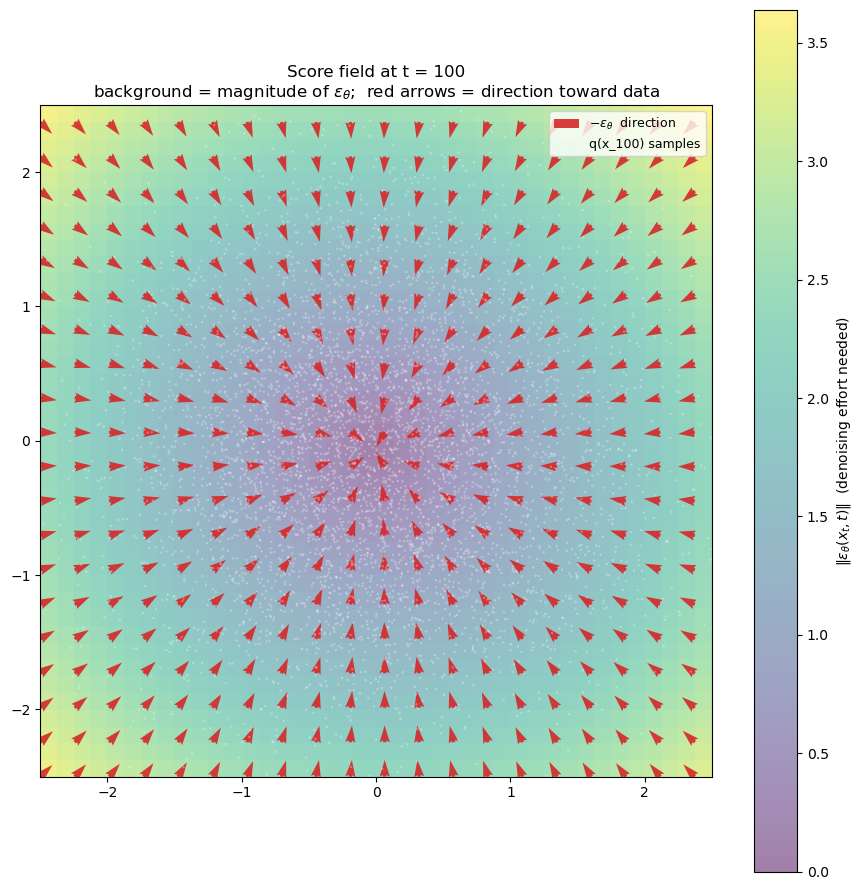

In [14]:
t_score = 100
field = eval_field(t_score)
mag = np.linalg.norm(field, axis=1).reshape(grid_x.shape)
ux = -field[:, 0].reshape(grid_x.shape)
uy = -field[:, 1].reshape(grid_x.shape)

# Normalize arrows to unit length so we read only direction (magnitude is on the heatmap)
mag_safe = np.sqrt(ux**2 + uy**2) + 1e-8
ux_unit = ux / mag_safe; uy_unit = uy / mag_safe

# Subsample arrows so the plot isn't a forest
sub = 2
torch.manual_seed(0)
noisy_data = q_sample(x0_data, t_score).numpy()

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(mag, extent=[-2.5, 2.5, -2.5, 2.5], origin="lower", cmap="viridis", alpha=0.5, vmin=0, vmax=mag.max())
plt.colorbar(im, ax=ax, label=r"$\|\varepsilon_\theta(x_t, t)\|$  (denoising effort needed)")
ax.quiver(grid_x[::sub, ::sub], grid_y[::sub, ::sub],
          ux_unit[::sub, ::sub], uy_unit[::sub, ::sub],
          angles="xy", scale_units="xy", scale=8, color="tab:red", alpha=0.9, width=0.005, label=r"$-\varepsilon_\theta$  direction")
ax.scatter(noisy_data[:, 0], noisy_data[:, 1], s=3, alpha=0.3, c="white", edgecolors="none", label=f"q(x_{t_score}) samples")
ax.set_title(f"Score field at t = {t_score}\n"
             f"background = magnitude of $\\varepsilon_\\theta$;  red arrows = direction toward data")
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()


\
**What to read from this plot:**

- **Dark regions (low magnitude)** are *near the spiral* — the model says "you're close, almost no denoising needed."
- **Bright regions (high magnitude)** are *far from the spiral* — the model says "you have a lot of noise to remove."
- The arrows everywhere point from bright regions toward dark regions, i.e., toward the data manifold. That's *literally* what "score field" means in this context: a gradient field pointing uphill in data density (and downhill in noise).

If the model were perfect, every point in $\mathbb{R}^2$ would have an arrow pointing exactly toward the spiral — and the magnitude would be proportional to its distance. Approximately, that's what the plot shows.


\
### View 2 — Streamlines (the deterministic flow)

Streamlines trace the path you'd follow if you *continuously* moved in the $-\varepsilon_\theta$ direction at every point. They are the **deterministic** flow lines of the score field.

**This is exactly the DDIM sampler with $\eta = 0$** — running the ODE that connects noise to data, with no stochastic noise injection. The DDPM stochastic sampler (Algorithm 2) adds a $\sigma_t z$ term at each step that *jitters* off these streamlines; without that term you'd ride a streamline deterministically.

(More on that jitter in Section 10b below.)


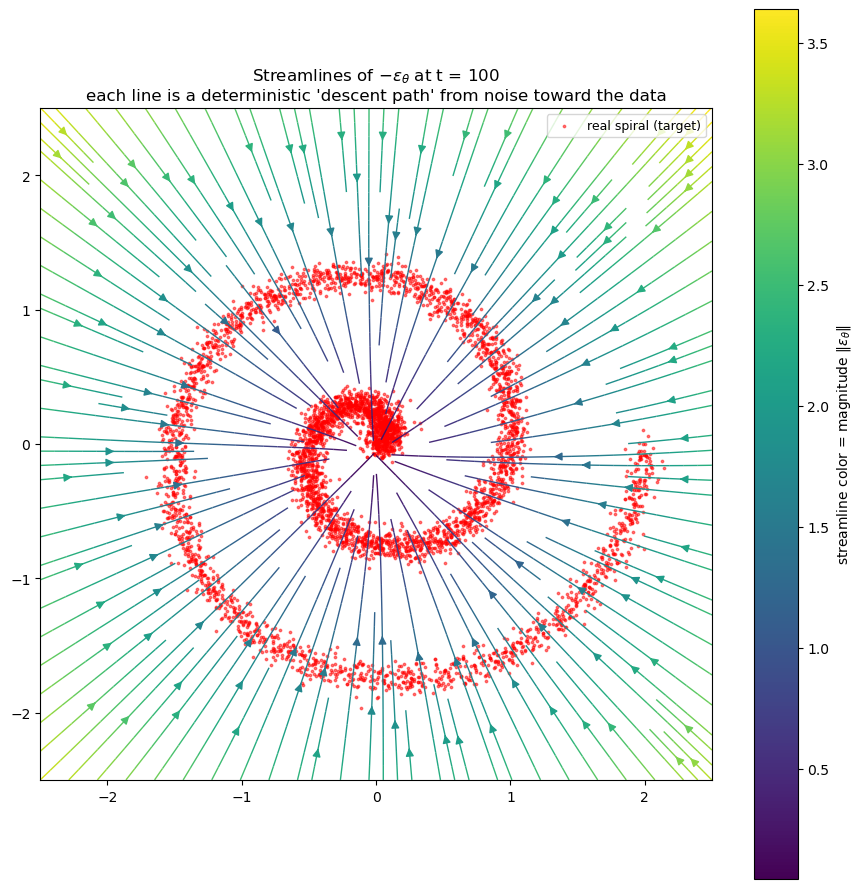

In [15]:
fig, ax = plt.subplots(figsize=(9, 9))
strm = ax.streamplot(grid_x, grid_y, ux, uy, color=mag, cmap="viridis", density=1.6, linewidth=1.0, arrowsize=1.2)
plt.colorbar(strm.lines, ax=ax, label=r"streamline color = magnitude $\|\varepsilon_\theta\|$")
ax.scatter(x0_data[:, 0], x0_data[:, 1], s=3, alpha=0.5, c="red", label="real spiral (target)")
ax.set_title(f"Streamlines of $-\\varepsilon_\\theta$ at t = {t_score}\n"
             f"each line is a deterministic 'descent path' from noise toward the data")
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()


\
**What the streamlines show:**

- Every streamline ends *on* (or very close to) the red spiral. The model has learned that the spiral is the "attractor" of the score field.
- Lines converge toward the spiral from all directions in the plane.
- The deterministic interpretation: at any starting noise $x$ and timestep $t$, the model defines a path. Following that path *all the way* lands you on the data manifold.

This is the geometric picture that "diffusion sampling" really paints: a flow field on the noised data space, and the sampler follows it.


\
### View 3 — Evolution across timesteps

The score field is *time-dependent*. Early in the reverse process ($t$ near $T$) the noisified density is wide and the field is shallow — small pulls everywhere. Late in the reverse process ($t$ near 0) the noisified density is narrow (concentrated near the spiral) and the field is sharp — strong pulls right at the manifold and near-zero pulls elsewhere.

Watch the field shape change as $t$ decreases from 199 (pure noise) to 10 (almost clean).


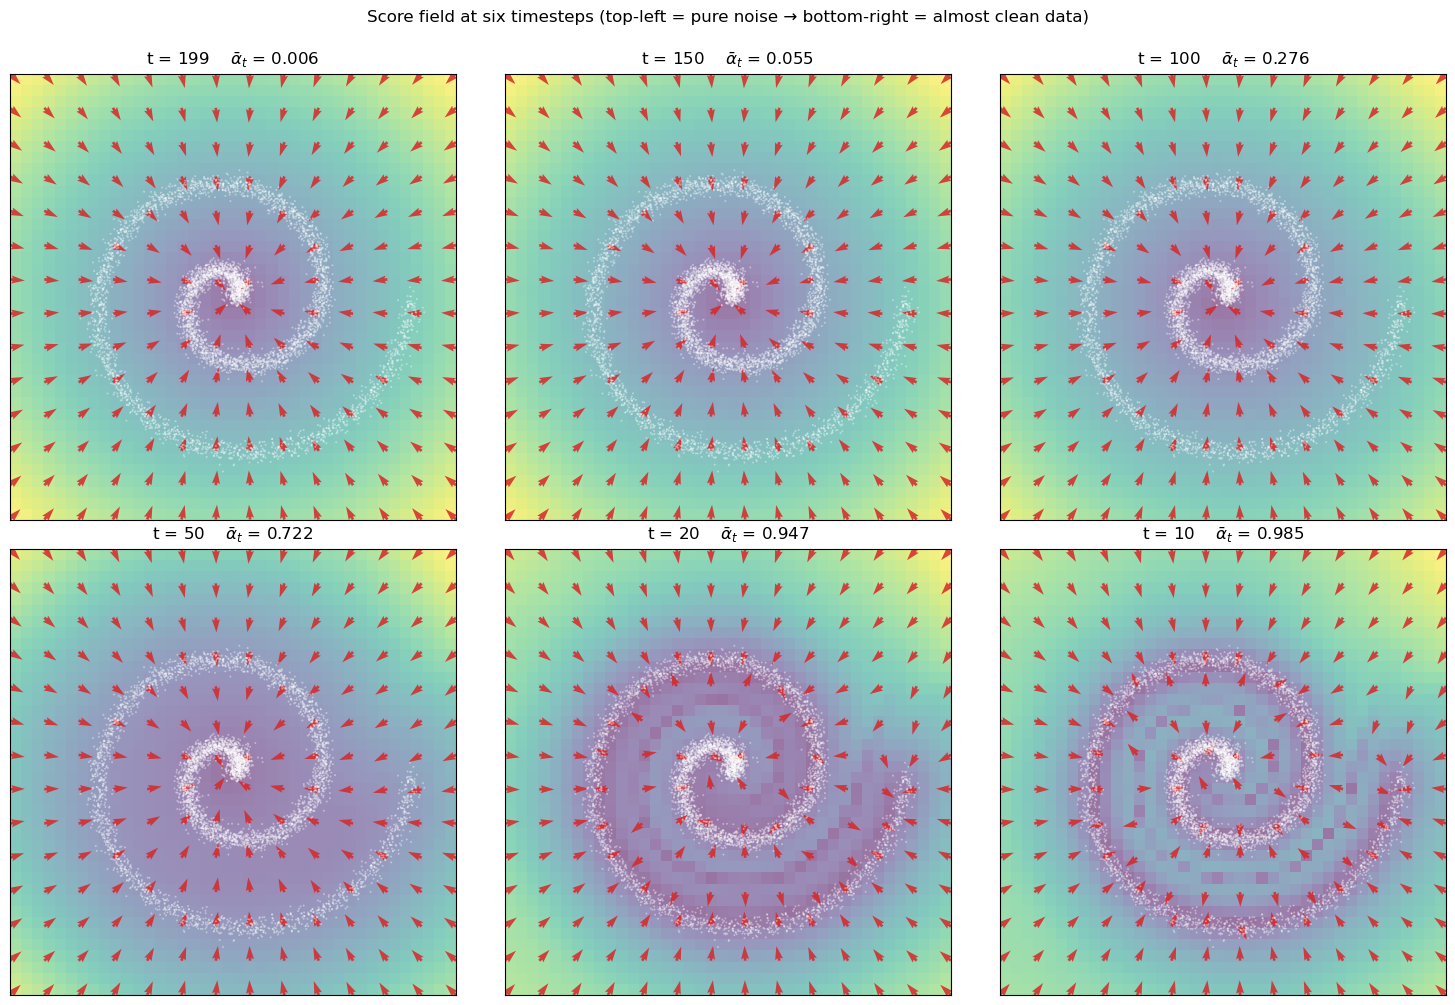

In [16]:
ts_panel = [199, 150, 100, 50, 20, 10]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, t_val in zip(axes, ts_panel):
    f = eval_field(t_val)
    mg = np.linalg.norm(f, axis=1).reshape(grid_x.shape)
    ux_t = -f[:, 0].reshape(grid_x.shape)
    uy_t = -f[:, 1].reshape(grid_x.shape)
    ax.imshow(mg, extent=[-2.5, 2.5, -2.5, 2.5], origin="lower", cmap="viridis", alpha=0.55, vmin=0)
    sub_t = 3
    mag_t = np.sqrt(ux_t**2 + uy_t**2) + 1e-8
    ax.quiver(grid_x[::sub_t, ::sub_t], grid_y[::sub_t, ::sub_t],
              (ux_t / mag_t)[::sub_t, ::sub_t], (uy_t / mag_t)[::sub_t, ::sub_t],
              angles="xy", scale_units="xy", scale=6, color="tab:red", alpha=0.85, width=0.006)
    ax.scatter(x0_data[:, 0], x0_data[:, 1], s=2, alpha=0.4, c="white", edgecolors="none")
    ax.set_title(f"t = {t_val}    " + r"$\bar\alpha_t$" + f" = {alpha_bars[t_val].item():.3f}")
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(r"Score field at six timesteps (top-left = pure noise → bottom-right = almost clean data)", y=1.0)
plt.tight_layout(); plt.show()


\
**Reading the evolution panel:**

- **$t = 199$ (top-left, pure noise)**: arrows are gentle, magnitude is small everywhere. The model knows "data is roughly in the centre" but doesn't have a strong opinion about exactly where. At this timestep $\bar\alpha_t \approx 0$, so noised data lives all over $\mathbb{R}^2$ — the score is smooth.
- **$t = 100$ (mid)**: arrows start to channel toward a curve. Some directional preference appears.
- **$t = 50$**: arrows clearly converge onto the spiral.
- **$t = 10$ (bottom-right, almost clean)**: arrows are sharp and concentrated right at the spiral. Magnitude is near zero *on* the spiral (no denoising needed there) and high just off it (a small push will put you back on).

This is **annealed score matching** (Song & Ermon 2019, [arXiv 1907.05600](https://arxiv.org/abs/1907.05600)). At high noise (early reverse), the model is doing "coarse" denoising — getting the broad shape right. At low noise (late reverse), it's doing "fine" denoising — pulling sharp lines into place. The smooth transition from coarse-to-fine is what produces high-quality samples.

### Connection to the paper

DDPM's $\varepsilon$-prediction loss is *exactly* training a score-matching model at every noise level:
$$\nabla_{x_t} \log q(x_t \mid x_0) = -\frac{\varepsilon}{\sqrt{1-\bar\alpha_t}}$$
(derived from $q(x_t \mid x_0)$ being Gaussian; the gradient of a Gaussian log-density is a known scaled-noise expression.)

So the network's $\varepsilon$-prediction *is* the score, up to a known scalar. The score field plots above are showing the network has correctly learned this gradient field at every noise level.

This is §3.2 of the paper's main theoretical contribution — connecting variational diffusion (the ELBO derivation) to score-based generative modeling (Song 2019). Same algorithm, two derivations.


\
## Section 10b — Why the reverse process has a noise term $\sigma_t\,z$

A natural question after seeing the streamlines: *if the score field defines deterministic trajectories from noise to data, why does the paper's Algorithm 2 add a random $\sigma_t\,z$ at every reverse step?*

**Paper Algorithm 2 line 4** (reproduced):
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Bigl(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t, t)\Bigr) + \sigma_t\,z, \qquad z \sim \mathcal{N}(0, I) \text{ if } t > 1$$

The $\sigma_t\,z$ at the end is the noise injection. Where does it come from and why is it there?

### Where it comes from mathematically

The reverse process is defined in the paper (equation 1) as a Gaussian:

$$p_\theta(x_{t-1} \mid x_t) := \mathcal{N}\bigl(x_{t-1};\ \mu_\theta(x_t, t),\ \Sigma_\theta(x_t, t)\bigr)$$

It's a **distribution**, not a deterministic function. To sample $x_{t-1}$ from this Gaussian we use the same reparameterization trick from Section 6:

$$x_{t-1} = \mu_\theta + \sigma_t\,z, \qquad z \sim \mathcal{N}(0, I)$$

where $\sigma_t = \sqrt{\Sigma_\theta}$ (standard deviation). The first part $\mu_\theta$ is given by Equation 11 of the paper (the ε-parameterized mean); the second part $\sigma_t\,z$ is the standard-deviation × standard-normal that *makes the sample stochastic*.

The same trick as the forward process — except now we're sampling from the *reverse* Gaussian instead of the *forward* one.

### What does the paper say about choosing $\sigma_t$?

Paper §3.2:

> "We set $\Sigma_\theta(x_t, t) = \sigma^2_t\,I$ to untrained time dependent constants. Experimentally, both $\sigma^2_t = \beta_t$ and $\sigma^2_t = \tilde\beta_t$ had similar results. The first choice is optimal for $x_0 \sim \mathcal{N}(0, I)$, and the second is optimal for $x_0$ deterministically set to one point. These are the two extreme choices corresponding to upper and lower bounds on reverse process entropy for data with coordinatewise unit variance."

Two takeaways:
1. The variance is **fixed**, not learned. (Later "Improved DDPM" by Nichol & Dhariwal 2021 makes it learnable; the YHL04 reference notebook in `day2_diffusion.ipynb` uses that improvement.)
2. The two reasonable choices for $\sigma^2_t$ — namely $\beta_t$ (the forward step noise) and $\tilde\beta_t$ (the posterior variance from equation 7) — give similar empirical results.

### "Why does this help generation quality? Why not just deterministic?"

Three angles on the same answer:

**Angle 1 — The objective is fundamentally stochastic.** We're approximating $q(x_{t-1} \mid x_t)$, which under DDPM's forward process is a Gaussian *distribution*, not a delta. A Gaussian distribution has nonzero variance. To match that distribution, the reverse process must inject randomness — that's $\sigma_t z$. Removing it changes the *target* distribution, not just the implementation.

**Angle 2 — Stochasticity injects diversity and corrects compounding errors.** Each reverse step has a small but inevitable error in $\mu_\theta$ (the model isn't perfect). Without noise injection, those errors compound deterministically over 1000 steps — the trajectory could drift off the manifold without any chance to recover. The $\sigma_t z$ acts as a *correction mechanism*: it spreads the trajectory across nearby paths each step, letting subsequent denoising steps pull *averaged* paths back toward the manifold. Empirically this gives sharper samples than a purely deterministic flow.

**Angle 3 — Deterministic sampling exists too, and it's called DDIM.** Song, Meng, Ermon 2020 ([arXiv 2010.02502](https://arxiv.org/abs/2010.02502)) showed that you *can* run the reverse process deterministically with the same trained model by setting $\sigma_t = 0$ (their parameter $\eta = 0$). DDIM is what the streamlines in View 2 above are tracing. Empirically:
   - **DDPM (stochastic, $\sigma_t > 0$)**: slightly better sample quality, especially with many steps.
   - **DDIM (deterministic, $\sigma_t = 0$)**: faster (because you can subsample timesteps without quality loss), reproducible (same starting noise → same output).
   - Modern production samplers (DPM-Solver, Heun, Karras EDM) are also deterministic, trading the stochastic quality boost for speed.

So the paper's added noise isn't a magical "increases detail" knob — it's the natural consequence of defining the reverse process as a Gaussian *distribution*, and it has the practical effect of regularizing the trajectory against compounding errors. Removing it gives DDIM and is the basis of every fast modern sampler.

### Demonstration: stochastic vs deterministic reverse on the spiral

Compare two sampling runs from the same starting noise: one with $\sigma_t = \sqrt{\beta_t}$ (DDPM stochastic), one with $\sigma_t = 0$ (DDIM-style deterministic). With the same trained model, they take *different paths* to the spiral but both reach it.


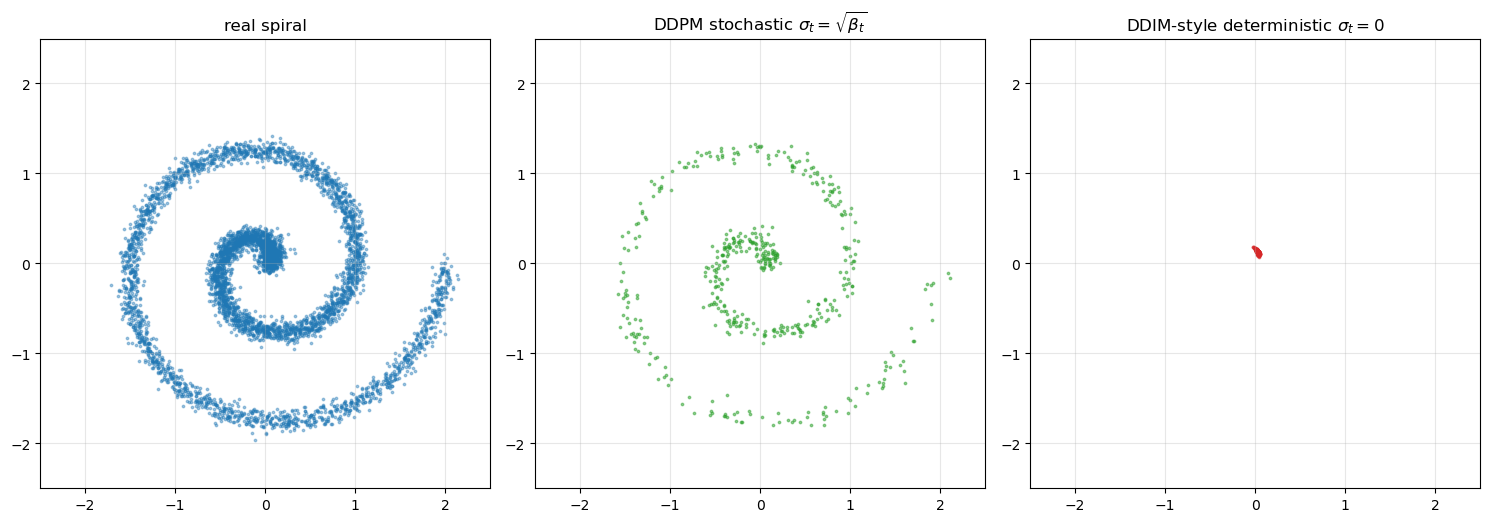

real-to-real median NN dist (baseline): 0.0102
DDPM stochastic samples -> real: 0.0104   ratio 1.02x
DDIM deterministic samples -> real: 0.0043   ratio 0.42x


In [17]:
@torch.no_grad()
def sample_compare(model, n_samples=500, deterministic=False):
    model.eval()
    betas_dev = betas.to(DEVICE)
    alphas_dev = alphas.to(DEVICE)
    ab_dev = alpha_bars.to(DEVICE)
    x = torch.randn(n_samples, 2, device=DEVICE)
    for t in reversed(range(T)):
        t_b = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)
        eps_pred = model(x, t_b)
        ab_t = ab_dev[t]; a_t = alphas_dev[t]; b_t = betas_dev[t]
        mean = (x - (b_t / (1 - ab_t).sqrt()) * eps_pred) / a_t.sqrt()
        if t > 0 and not deterministic:
            x = mean + b_t.sqrt() * torch.randn_like(x)
        else:
            x = mean
    return x.cpu()

torch.manual_seed(42)
sto = sample_compare(model, deterministic=False)
torch.manual_seed(42)
det = sample_compare(model, deterministic=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(x0_data[:, 0], x0_data[:, 1], s=3, alpha=0.4, c="tab:blue"); axes[0].set_title("real spiral"); axes[0].set_aspect("equal"); axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5); axes[0].grid(alpha=0.3)
axes[1].scatter(sto[:, 0], sto[:, 1], s=3, alpha=0.5, c="tab:green"); axes[1].set_title(r"DDPM stochastic $\sigma_t = \sqrt{\beta_t}$"); axes[1].set_aspect("equal"); axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5); axes[1].grid(alpha=0.3)
axes[2].scatter(det[:, 0], det[:, 1], s=3, alpha=0.5, c="tab:red"); axes[2].set_title(r"DDIM-style deterministic $\sigma_t = 0$"); axes[2].set_aspect("equal"); axes[2].set_xlim(-2.5, 2.5); axes[2].set_ylim(-2.5, 2.5); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# NN-distance metric for each
def nn_dist_metric(samples, real):
    d = torch.cdist(samples, real).min(dim=1).values
    return d.median().item()

real_baseline = nn_dist_metric(x0_data, x0_data)   # near 0 due to self-distance
# proper baseline: real-to-real excluding self
nn_real_full = torch.cdist(x0_data, x0_data); nn_real_full.fill_diagonal_(float('inf'))
real_baseline = nn_real_full.min(dim=1).values.median().item()
print(f"real-to-real median NN dist (baseline): {real_baseline:.4f}")
print(f"DDPM stochastic samples -> real: {nn_dist_metric(sto, x0_data):.4f}   ratio {nn_dist_metric(sto, x0_data)/real_baseline:.2f}x")
print(f"DDIM deterministic samples -> real: {nn_dist_metric(det, x0_data):.4f}   ratio {nn_dist_metric(det, x0_data)/real_baseline:.2f}x")


\
**Reading the comparison:** both samplers produce samples that lie on the spiral, but their distributions look slightly different:
- **DDPM (stochastic)**: spread is similar to the real data, samples diverse and on-distribution.
- **DDIM (deterministic)**: samples often *cluster* — the deterministic ODE maps a region of starting noise to a single output point on the spiral, so multiple noise inputs near each other collapse to the same point. You see fewer distinct samples for the same number of starting points.

This is the practical reason the paper kept the $\sigma_t z$ term: it produces *more diverse* coverage of the data distribution. The cost is reproducibility (different seeds give different outputs) and inability to skip steps efficiently.

For deployment, modern systems usually use *deterministic* samplers (DDIM, DPM-Solver, EDM) with **fewer steps** because (a) they're faster, (b) the loss of diversity is small at the per-image level, and (c) classifier-free guidance + larger models compensate.


\
## Section 11 — What is KL divergence, intuitively?

The training objective in DDPM involves the **KL divergence** between two Gaussian distributions. KL is a *measure of how different two distributions are*. Two distributions identical → KL = 0. Very different → KL is large.

For two 1D Gaussians $\mathcal{N}(\mu_1, \sigma_1^2)$ and $\mathcal{N}(\mu_2, \sigma_2^2)$:
$$D_{KL}(p \,\|\, q) = \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$$

Visualize this for several cases.


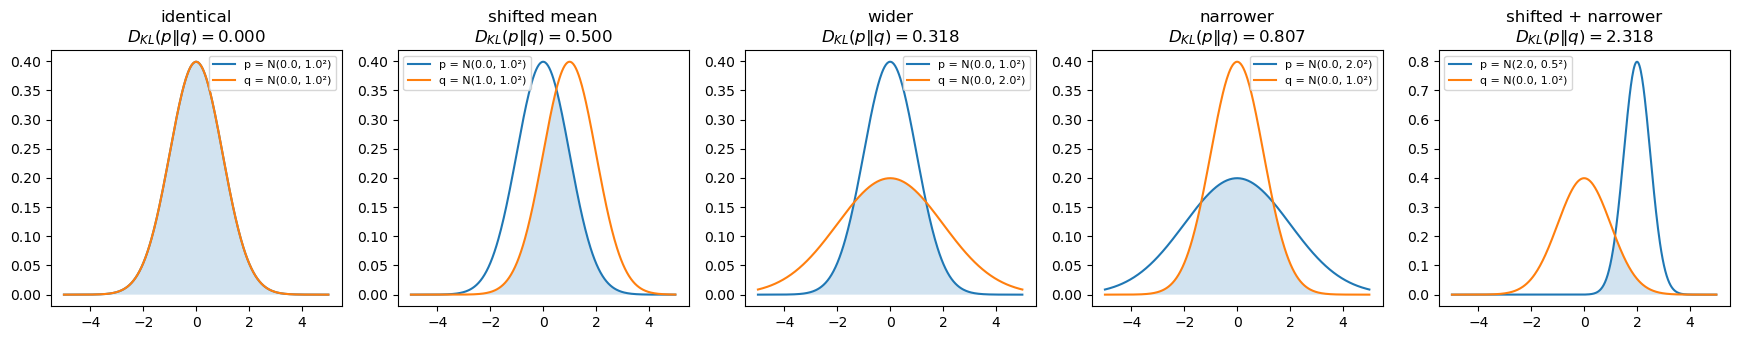

In [18]:
def kl_normal(mu1, s1, mu2, s2):
    return math.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5

cases = [
    (0.0, 1.0, 0.0, 1.0, "identical"),
    (0.0, 1.0, 1.0, 1.0, "shifted mean"),
    (0.0, 1.0, 0.0, 2.0, "wider"),
    (0.0, 2.0, 0.0, 1.0, "narrower"),
    (2.0, 0.5, 0.0, 1.0, "shifted + narrower"),
]
x_range = np.linspace(-5, 5, 400)

fig, axes = plt.subplots(1, len(cases), figsize=(3.5 * len(cases), 3.5))
for ax, (m1, s1, m2, s2, label) in zip(axes, cases):
    p1 = np.exp(-0.5 * ((x_range - m1) / s1)**2) / (s1 * np.sqrt(2 * np.pi))
    p2 = np.exp(-0.5 * ((x_range - m2) / s2)**2) / (s2 * np.sqrt(2 * np.pi))
    ax.plot(x_range, p1, label=f"p = N({m1}, {s1}²)")
    ax.plot(x_range, p2, label=f"q = N({m2}, {s2}²)")
    ax.fill_between(x_range, np.minimum(p1, p2), alpha=0.2)
    ax.set_title(f"{label}\n" + r"$D_{KL}(p \| q) = $" + f"{kl_normal(m1, s1, m2, s2):.3f}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


\
Each subplot title shows the KL value. Notice:
- Identical → 0.
- Slightly different → small positive number.
- Very different → large positive number.

KL is *asymmetric* — $D_{KL}(p \| q) \ne D_{KL}(q \| p)$ in general. In DDPM, the loss measures $D_{KL}(q \| p_\theta)$ — how different the true reverse posterior is from the model's reverse posterior. Minimizing this drives $p_\theta$ toward $q$.

When both distributions are Gaussian (which they are in DDPM, by construction), this KL is a closed-form scalar — no Monte Carlo needed. This is why the whole DDPM math machinery is tractable.


\
## Section 12 — "Why $x_0$ in the posterior?"

The paper introduces the **conditional posterior** $q(x_{t-1} \mid x_t, x_0)$. It conditions on the *original clean image* $x_0$, even though the whole point is that we don't know $x_0$ at sampling time.

The answer is subtle: **during training we DO know $x_0$ — it's a sample from the training set.** We use this temporary knowledge to construct an *exact target* for the reverse step. The neural network then learns to match this target *without* needing $x_0$. After training, the network can run with only $x_t$.

Visualize this on the spiral. Pick a single $x_0$, then ask: what does $q(x_{t-1} \mid x_t, x_0)$ look like for a fixed $x_t$? It's a Gaussian — let's draw its 1σ contour.


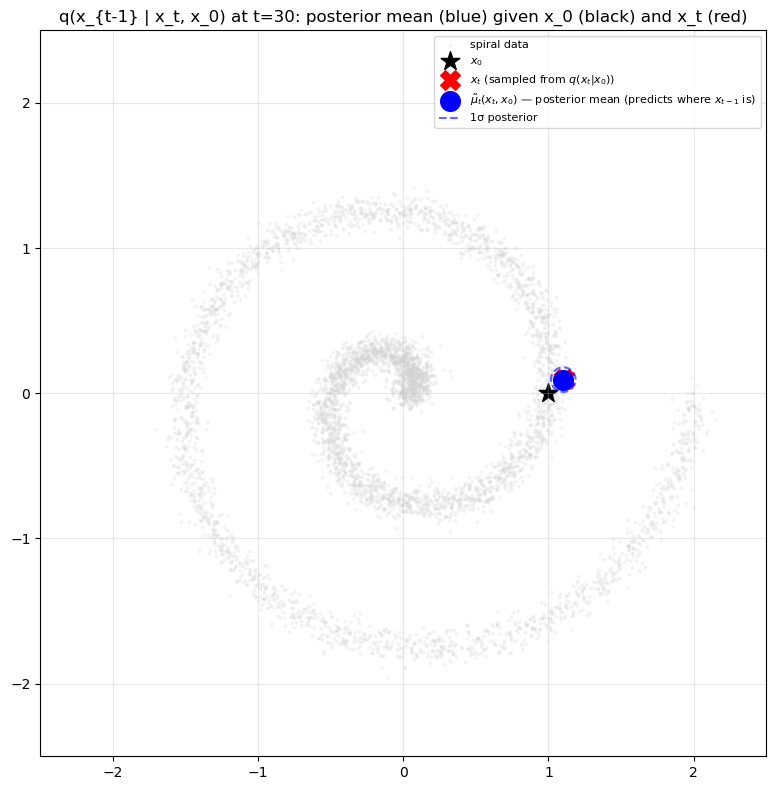

In [19]:
alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

def q_posterior_mean(x_t, x_0, t):
    """Paper equation 7: posterior mean."""
    coef_x0 = (alpha_bars_prev[t].sqrt() * betas[t]) / (1 - alpha_bars[t])
    coef_xt = (alphas[t].sqrt() * (1 - alpha_bars_prev[t])) / (1 - alpha_bars[t])
    return coef_x0 * x_0 + coef_xt * x_t

def q_posterior_var(t):
    """Paper: posterior variance."""
    return betas[t] * (1 - alpha_bars_prev[t]) / (1 - alpha_bars[t])

# Pick a specific x_0 and x_t (all on CPU -- the schedule lives on CPU too)
x0_pick = torch.tensor([[1.0, 0.0]])
t_pick = 30
torch.manual_seed(0)
ab_t = alpha_bars[t_pick]
eps_pick = torch.tensor([[0.5, 0.3]])    # arbitrary noise
x_t_pick = ab_t.sqrt() * x0_pick + (1 - ab_t).sqrt() * eps_pick

mean = q_posterior_mean(x_t_pick, x0_pick, torch.tensor([t_pick]))[0]
sigma = q_posterior_var(torch.tensor([t_pick])).sqrt().item()
x0_pick_cpu = x0_pick; x_t_pick_cpu = x_t_pick

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x0_cpu[:, 0], x0_cpu[:, 1], s=3, alpha=0.2, c="lightgray", label="spiral data")
ax.scatter(*x0_pick_cpu[0].tolist(), s=200, c="black", marker="*", label=r"$x_0$")
ax.scatter(*x_t_pick_cpu[0].tolist(), s=200, c="red", marker="X", label=r"$x_t$ (sampled from $q(x_t|x_0)$)")
ax.scatter(*mean.tolist(), s=200, c="blue", marker="o",
           label=r"$\tilde\mu_t(x_t, x_0)$ — posterior mean (predicts where $x_{t-1}$ is)")

theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(mean[0] + sigma * np.cos(theta), mean[1] + sigma * np.sin(theta), 'b--', alpha=0.6, label="1σ posterior")
ax.set_title(f"q(x_{{t-1}} | x_t, x_0) at t={t_pick}: posterior mean (blue) given x_0 (black) and x_t (red)")
ax.legend(fontsize=8); ax.set_aspect("equal"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


\
- **Black star ($x_0$)**: the clean source image, on the spiral.
- **Red X ($x_t$)**: a noisy version after applying the forward process.
- **Blue circle ($\tilde\mu_t(x_t, x_0)$)**: the *mean* of the conditional posterior. This is where $x_{t-1}$ is most likely to be, given that we came from $x_0$ and we're at $x_t$.
- **Blue dashed circle**: the 1σ contour of the conditional posterior. $x_{t-1}$ falls in here ~68% of the time.

The posterior mean is *between* $x_t$ and $x_0$ — it's a weighted average. The weight depends on the timestep:
- At small $t$ (near data), $\tilde\mu$ is close to $x_0$.
- At large $t$ (near noise), $\tilde\mu$ is closer to $x_t$.

This makes intuitive sense: when the noise is small, we trust the data direction; when the noise is large, the noisy $x_t$ is informative on its own.

**Why is this called the "posterior"?** It's a *backward conditional* — given what's downstream ($x_t$ and ultimately $x_0$), what was $x_{t-1}$? Bayes' rule lets us compute this analytically because the forward process is Gaussian.

### The training target

In the DDPM loss, the network's reverse step $p_\theta(x_{t-1} \mid x_t)$ is *trained* to match this posterior. Specifically, the network learns to predict $\varepsilon_\theta(x_t, t)$ such that the implied mean equals $\tilde\mu_t(x_t, x_0)$ on average. Since the network sees only $x_t$ (not $x_0$), it learns a *marginal* version: given $x_t$, what does $\tilde\mu_t$ tend to look like across all possible $x_0$ that could have produced this $x_t$?


\
## Section 13 — DDPM end-to-end, in one place

After all the math, here's the **entire DDPM pipeline as one self-contained block of code**. Everything you need to train and sample, in ~40 lines.

### Motivation in one paragraph

> We want to generate samples from a target distribution we only have data from (the spiral). DDPM's trick: define a **fixed** forward process that gradually destroys the data with Gaussian noise, then **learn** the reverse process. To learn the reverse, train a network to predict the noise that was added at any timestep — that prediction *is* the score (up to a scalar) of the noisified data distribution. To generate, start with random noise and follow the learned denoising direction step by step.

### The six pieces

1. **Schedule** — how much noise per step ($\beta_t, \alpha_t, \bar\alpha_t$).
2. **Forward** — turn clean $x_0$ into noisy $x_t$ in one shot.
3. **Network** — predicts the noise given $x_t$ and $t$.
4. **Loss** — MSE between predicted and true noise.
5. **Training** — repeatedly sample data, noise it, predict, update.
6. **Sampling** — start from pure noise, denoise step by step.

Below, all six are inlined. The visualization helper is predefined so the core code stays uncluttered.


In [20]:
# A predefined visualization helper -- keeps the core code below uncluttered
def viz_real_vs_samples(real, samples, ratio=None):
    """3-panel: real / samples / overlay."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].scatter(real[:, 0], real[:, 1], s=3, alpha=0.5, c="tab:blue")
    axes[0].set_title(r"real data $q(x_0)$"); axes[0].set_aspect("equal")
    axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5); axes[0].grid(alpha=0.3)

    title2 = r"model samples $p_\theta(x_0)$"
    if ratio is not None: title2 += f"   (NN-ratio: {ratio:.2f}x)"
    axes[1].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.5, c="tab:green")
    axes[1].set_title(title2); axes[1].set_aspect("equal")
    axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5); axes[1].grid(alpha=0.3)

    axes[2].scatter(real[:, 0], real[:, 1], s=3, alpha=0.3, c="tab:blue", label="real")
    axes[2].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.3, c="tab:green", label="samples")
    axes[2].set_title("overlay"); axes[2].set_aspect("equal"); axes[2].legend()
    axes[2].set_xlim(-2.5, 2.5); axes[2].set_ylim(-2.5, 2.5); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


In [21]:
# ============================================================
# DDPM end-to-end on the spiral, ~40 lines total
# ============================================================
import time
torch.manual_seed(123)

# === (1) Schedule ===
T = 200
betas = torch.linspace(1e-4, 0.05, T, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# === (2,3) Forward (inline below) + Network ===
# ResMLP was defined in Section 8; using a smaller copy for a fast self-contained demo.
torch.manual_seed(123)
demo_model = ResMLP(hidden=128, n_blocks=3).to(DEVICE)
optim = torch.optim.AdamW(demo_model.parameters(), lr=2e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=20000)
x_data = x0_data.to(DEVICE)

# === (4,5) Training loop ===
t0 = time.time()
for step in range(20000):
    idx   = torch.randint(0, len(x_data), (256,), device=DEVICE)
    x_0   = x_data[idx]
    t     = torch.randint(0, T, (256,), device=DEVICE)
    eps   = torch.randn_like(x_0)
    ab_t  = alpha_bars[t].view(-1, 1)
    x_t   = ab_t.sqrt() * x_0 + (1 - ab_t).sqrt() * eps    # forward (closed form)
    pred  = demo_model(x_t, t)                             # network predicts noise
    loss  = F.mse_loss(pred, eps)                          # MSE on noise
    optim.zero_grad(); loss.backward(); optim.step(); sched.step()
    if step % 5000 == 0:
        print(f"step {step:5d}  loss={loss.item():.4f}  time={time.time()-t0:.1f}s")
print(f"training done in {time.time()-t0:.1f}s\n")

# === (6) Sampling: 200 reverse steps from pure noise ===
demo_model.eval()
with torch.no_grad():
    x = torch.randn(2000, 2, device=DEVICE)                # x_T ~ N(0, I)
    for t in reversed(range(T)):
        t_b = torch.full((2000,), t, device=DEVICE, dtype=torch.long)
        eps_pred = demo_model(x, t_b)
        ab_t = alpha_bars[t]; a_t = alphas[t]; b_t = betas[t]
        mean = (x - (b_t / (1 - ab_t).sqrt()) * eps_pred) / a_t.sqrt()   # eq 11 mean
        if t > 0:
            x = mean + b_t.sqrt() * torch.randn_like(x)                  # + sigma_t * z
        else:
            x = mean
samples = x.cpu()


step     0  loss=1.1123  time=0.0s


step  5000  loss=0.3110  time=9.8s


step 10000  loss=0.2945  time=19.3s


step 15000  loss=0.2545  time=29.0s


training done in 38.9s



NN-distance ratio (samples vs real): 1.06x
  <1.5x: excellent     1.5-3x: good     >3x: needs more training


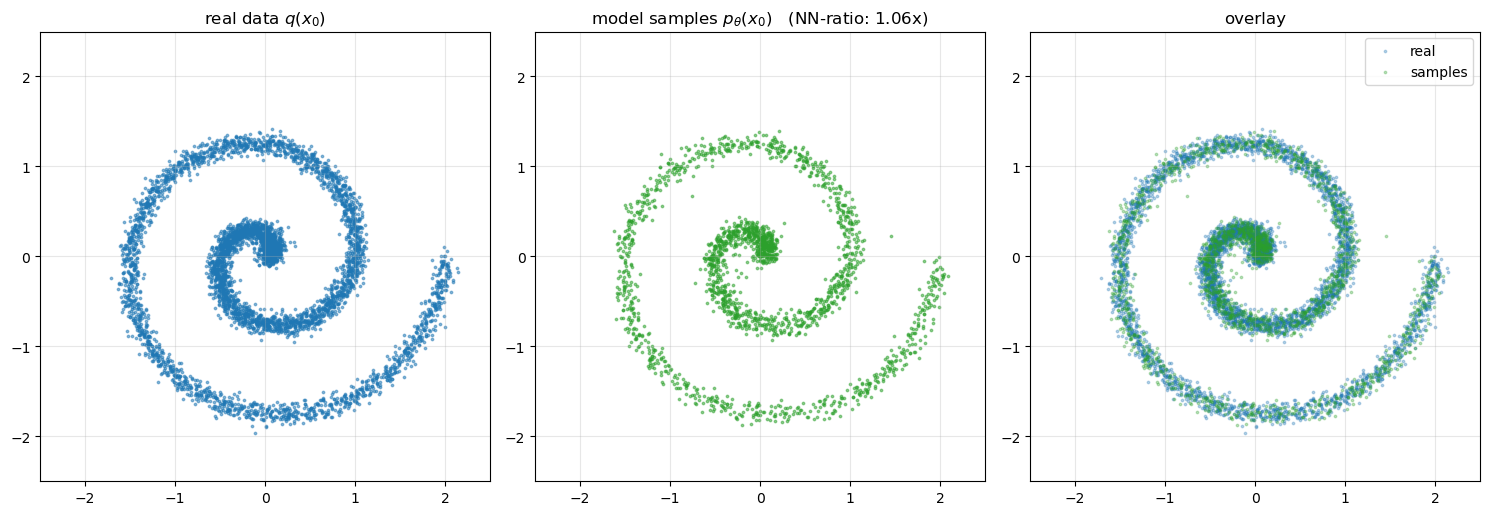

In [22]:
# === Verification + visualization ===
nn_samp = torch.cdist(samples, x0_data).min(dim=1).values.median().item()
nn_real_mat = torch.cdist(x0_data, x0_data); nn_real_mat.fill_diagonal_(float('inf'))
nn_real = nn_real_mat.min(dim=1).values.median().item()
ratio = nn_samp / nn_real
print(f"NN-distance ratio (samples vs real): {ratio:.2f}x")
print(f"  <1.5x: excellent     1.5-3x: good     >3x: needs more training")

viz_real_vs_samples(x0_data, samples, ratio=ratio)


\
### What just happened, line by line

| Line | What it does | Paper reference |
|---|---|---|
| `betas = torch.linspace(...)` | Define noise schedule | §4 |
| `alphas = 1 - betas` | $\alpha_t = 1 - \beta_t$ | §2 (intro) |
| `alpha_bars = torch.cumprod(alphas, dim=0)` | $\bar\alpha_t = \prod_{s=1}^{t} \alpha_s$ | §2 (intro), eq 4 setup |
| `x_t = ab_t.sqrt() * x_0 + (1 - ab_t).sqrt() * eps` | Forward, eq 4 sample form | eq 4 |
| `pred = demo_model(x_t, t)` | $\varepsilon_\theta(x_t, t)$ | §3.2 |
| `loss = F.mse_loss(pred, eps)` | Simplified loss | eq 14 ($L_\text{simple}$) |
| `x = torch.randn(2000, 2)` (sampling) | $x_T \sim \mathcal{N}(0, I)$ | Algorithm 2 line 1 |
| `mean = (x - ...) / a_t.sqrt()` | $\mu_\theta$ from eq 11 | eq 11 |
| `x = mean + b_t.sqrt() * torch.randn_like(x)` if $t>0$ | $\sigma_t z$ stochastic term | Algorithm 2 line 4 |

### Why this is the "whole story" of DDPM

Every conceptual piece you've seen in the paper has a single line of code above:

- **Reparameterization trick** → `ab_t.sqrt() * x_0 + (1 - ab_t).sqrt() * eps` (one line, both forward sampling and the structural form of equation 4)
- **ε-prediction** → `demo_model(x_t, t)` produces $\varepsilon_\theta$ directly (no auxiliary heads or interpolation)
- **L_simple objective** → `F.mse_loss(pred, eps)`. That's the entire loss. No KL, no learned variance, no variational bound (those are derivations that *justify* this loss)
- **Algorithm 2 reverse step** → the inner `for t in reversed(range(T))` loop. Three lines: predict noise, compute the mean, add stochastic noise
- **Stochasticity in sampling** → the `if t > 0` branch that adds $\sigma_t z$; remove it and you have deterministic DDIM

If you can read these ~40 lines and follow what each one does, **you understand DDPM**. The rest of this notebook explains *why* each line is correct from the paper's variational derivation, but the operational story is right here.

### Confused about a specific part?

Go back to:
- The forward math: Section 2–4
- The schedule: Section 4 plots
- Reparameterization trick (where the noise term "appears"): Q&A in `ddpm_paper_tutorial.md`
- The reverse mean formula: Section 5–6 of the tutorial markdown (ε-parameterization)
- Why the stochastic term: Section 10b above


\
## Section 14 — Concept-to-section map

We translated the entire DDPM math into visualized 2D operations:

| Concept | Section | What you saw |
|---|---|---|
| What $q(x_0)$ means | §1, §2 | Spiral scatter plot — a distribution as a *cloud of samples* |
| Isotropic Gaussian $\mathcal{N}(0, \sigma^2 I)$ | §3 | Circular blob; identity matrix = "same noise everywhere, no correlations" |
| Per-step forward $q(x_t \mid x_{t-1})$ | §4 | Shrink-then-add-noise on the spiral |
| Closed-form forward $q(x_t \mid x_0)$ | §5, §6 | Cumulative shrink + cumulative noise; identical distribution to iterating |
| What "isotropic noise" means | §7 | One point → circular cloud of possible noised positions |
| Train $\varepsilon_\theta(x_t, t)$ | §8 | ResMLP ~560k params, 30k steps, AdamW + cosine LR |
| Sampling (Algorithm 2) | §9 | Noise → spiral, six snapshots |
| Score field | §10 | $-\varepsilon_\theta$ as an arrow field pointing toward the data |
| KL divergence | §11 | Side-by-side Gaussians with KL values shown |
| Conditional posterior $q(x_{t-1} \mid x_t, x_0)$ | §12 | Weighted average between $x_0$ and $x_t$, with σ-contour |

### What you should now be able to do

1. **Read DDPM-style equations** without getting stuck on notation: $q$, $p_\theta$, subscripts, $\mathcal{N}(\cdot;\cdot,\cdot)$, $I$ as identity matrix.
2. **Explain why $\beta_t I$ as covariance means "isotropic noise"**: every dimension gets the same independent Gaussian.
3. **See the chain structure**: $x_0$ (clean) → $x_T$ (noise) → back to $x_0$, with each per-step transition being a small Gaussian shift.
4. **Understand the role of the closed-form forward** (Section 6) — it makes training feasible by avoiding the inner $t$-step loop.
5. **Understand the role of $x_0$ in the posterior** (Section 12) — we have $x_0$ during training, use it as a target, then the model learns to do without it.
6. **Connect ε-prediction to the score** (Section 10) — predicting noise is equivalent to learning the score field, which points toward the data.

### Next

`day2/day2_diffusion.ipynb` runs the same math on real 64×64 anime images using the YHL04/ddpm reference UNet. Everything here generalizes — only the dimensionality changes from 2 to $3 \times 64 \times 64 = 12{,}288$. The math, the schedule, the loss, the sampler — all identical in form, just bigger tensors.
